In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureRavdess.csv')

In [3]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037,1,1,1
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626,1,1,1
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532,1,1,1
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753,1,1,1
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015,0,8,24
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375,0,8,24
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219,0,8,24
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220,0,8,24


In [5]:
import joblib

# Load the saved scaler
scaler = joblib.load("../scaler.pkl")

# Load the saved model
gender_model = tf.keras.models.load_model("../gender_classification_model.h5")

W0000 00:00:1764843546.831204 3976680 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
X_gender = data.iloc[:, :193].values
X_scaled = scaler.transform(X_gender)
gender_predictions = gender_model.predict(X_scaled)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step


In [7]:
print(gender_predictions)

[[7.7384239e-04]
 [7.8950549e-04]
 [1.0120951e-03]
 ...
 [9.9847502e-01]
 [9.9787855e-01]
 [9.9846315e-01]]


In [8]:
male_rows = gender_predictions.flatten() >= 0.5  # 0 for Male, 1 for Female

df = data[male_rows]

print(f"Filtered dataset contains {df.shape[0]} female samples.")

Filtered dataset contains 721 female samples.


In [9]:
df.shape

(721, 196)

In [10]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
60,-626.065857,67.129211,-14.506104,13.734784,-8.915299,-0.597560,-9.627712,-6.697053,-7.643127,1.682984,...,32.684056,-0.035477,0.046495,0.018824,-0.060412,0.011128,0.000489,0,1,2
61,-622.978882,61.610241,-16.155281,17.274385,-10.515155,-0.012929,-9.384588,-5.405496,-6.061921,0.427206,...,32.054128,-0.038423,0.033620,0.028817,-0.024666,0.011614,-0.008258,0,1,2
62,-594.977844,62.693829,-16.257780,9.051161,-9.175509,-0.249130,-9.898236,-7.671722,-8.782819,0.426915,...,31.869979,-0.053699,0.053169,0.032318,-0.044163,0.002315,-0.013748,0,1,2
63,-612.936279,58.990162,-15.687172,10.080914,-11.711167,-1.830589,-11.331991,-8.769240,-10.589375,-0.807020,...,31.140206,-0.045528,0.042565,-0.070671,-0.055261,0.010003,-0.008018,0,1,2
64,-639.557617,64.624420,-8.859457,17.944416,-9.782133,2.161584,-7.936422,-4.958043,-6.853294,0.523445,...,31.837218,-0.089607,0.068644,-0.019986,-0.011248,0.001546,0.004188,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015,0,8,24
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375,0,8,24
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219,0,8,24
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220,0,8,24


In [11]:
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [12]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
60,-626.065857,67.129211,-14.506104,13.734784,-8.915299,-0.597560,-9.627712,-6.697053,-7.643127,1.682984,...,15.032267,17.122944,17.137267,32.684056,-0.035477,0.046495,0.018824,-0.060412,0.011128,0.000489
61,-622.978882,61.610241,-16.155281,17.274385,-10.515155,-0.012929,-9.384588,-5.405496,-6.061921,0.427206,...,15.800671,16.939402,16.786359,32.054128,-0.038423,0.033620,0.028817,-0.024666,0.011614,-0.008258
62,-594.977844,62.693829,-16.257780,9.051161,-9.175509,-0.249130,-9.898236,-7.671722,-8.782819,0.426915,...,15.484927,17.181703,18.043089,31.869979,-0.053699,0.053169,0.032318,-0.044163,0.002315,-0.013748
63,-612.936279,58.990162,-15.687172,10.080914,-11.711167,-1.830589,-11.331991,-8.769240,-10.589375,-0.807020,...,15.257555,16.719364,17.726324,31.140206,-0.045528,0.042565,-0.070671,-0.055261,0.010003,-0.008018
64,-639.557617,64.624420,-8.859457,17.944416,-9.782133,2.161584,-7.936422,-4.958043,-6.853294,0.523445,...,16.251168,17.629721,16.558219,31.837218,-0.089607,0.068644,-0.019986,-0.011248,0.001546,0.004188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,16.391113,18.151034,17.573820,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,16.270073,17.091367,17.932740,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,16.128660,16.947312,18.503842,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,16.307834,17.859030,17.360766,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220


In [13]:
y

60      1
61      1
62      1
63      1
64      2
       ..
1435    8
1436    8
1437    8
1438    8
1439    8
Name: 0.2, Length: 721, dtype: int64

In [14]:
X.shape, y.shape

((721, 193), (721,))

In [15]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [16]:
y1

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(721, 8))

In [17]:
X.shape, y1.shape

((721, 193), (721, 8))

In [18]:
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [19]:
X2.shape, y2.shape

((721, 193), (721,))

In [20]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(8))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    return model

In [21]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [22]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-626.065857,67.129211,-14.506104,13.734784,-8.915299,-0.597560,-9.627712,-6.697053,-7.643127,1.682984,...,15.032267,17.122944,17.137267,32.684056,-0.035477,0.046495,0.018824,-0.060412,0.011128,0.000489
1,-622.978882,61.610241,-16.155281,17.274385,-10.515155,-0.012929,-9.384588,-5.405496,-6.061921,0.427206,...,15.800671,16.939402,16.786359,32.054128,-0.038423,0.033620,0.028817,-0.024666,0.011614,-0.008258
2,-594.977844,62.693829,-16.257780,9.051161,-9.175509,-0.249130,-9.898236,-7.671722,-8.782819,0.426915,...,15.484927,17.181703,18.043089,31.869979,-0.053699,0.053169,0.032318,-0.044163,0.002315,-0.013748
3,-612.936279,58.990162,-15.687172,10.080914,-11.711167,-1.830589,-11.331991,-8.769240,-10.589375,-0.807020,...,15.257555,16.719364,17.726324,31.140206,-0.045528,0.042565,-0.070671,-0.055261,0.010003,-0.008018
4,-639.557617,64.624420,-8.859457,17.944416,-9.782133,2.161584,-7.936422,-4.958043,-6.853294,0.523445,...,16.251168,17.629721,16.558219,31.837218,-0.089607,0.068644,-0.019986,-0.011248,0.001546,0.004188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,16.391113,18.151034,17.573820,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015
717,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,16.270073,17.091367,17.932740,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375
718,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,16.128660,16.947312,18.503842,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219
719,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,16.307834,17.859030,17.360766,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220


In [53]:
def fisher_score_manual(X, y):
    n_samples, n_features = X.shape
    classes = np.unique(y)
    score = np.zeros(n_features)
    for i in range(n_features):
        numerator = 0
        denominator = 0
        overall_mean = np.mean(X[:, i])
        for c in classes:
            Xc = X[y==c, i]
            nc = len(Xc)
            mean_c = np.mean(Xc)
            var_c = np.var(Xc)
            numerator += nc * (mean_c - overall_mean)**2
            denominator += nc * var_c
        score[i] = numerator / denominator if denominator != 0 else 0
    return score

In [55]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=720
num_fea=125
a=create_index(kfold,totalsize)
savedir='ravdess_gender_female'

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=kfold, shuffle=True, random_state=42)
top_features_per_fold = []
importance_per_fold = []

fold = 0
for train_idx, test_idx in skf.split(X3, y2):
    print(f"\n===== Fold {fold} =====")
    print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")

    # Split data
    X_train, X_test = X3.iloc[train_idx, :], X3.iloc[test_idx, :]
    y_train, y_test = y1[train_idx, :], y1[test_idx, :]
    y_train_fs, y_test_fs = y2[train_idx], y2[test_idx]  # for fisher score

    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)


    # Fisher score feature selection (on training data only)
    score = fisher_score_manual(X_train_scaled, y_train_fs)

    # Sort features by score (high → low)
    sorted_indices = np.argsort(score)[::-1]

    # Select top features
    fs_indices = sorted_indices[:num_fea]

    # Get scores of selected features
    selected_scores = score[fs_indices]

    # Compute relative importance (percentage)
    relative_importance = selected_scores / selected_scores.sum() * 100

    top_features_per_fold.append(fs_indices)
    importance_per_fold.append(relative_importance)

    print(f"Top {num_fea} features: {fs_indices} ...")
    print("Importances %:", relative_importance)
    print("Scores:", selected_scores)

    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    fold += 1
    


===== Fold 0 =====
Train: 576 | Test: 145
Top 125 features: [  0   2   1 185  20   5 153  21   3 154   4 155 183  35  22 182 157 184
  17 151  19 140 142  23 150  34 141 139  18 132 186  45  36 152 156 171
  44 143 130 144 179 129 138 131 166 123  74 177 133 158 174  75   7  87
  78 136  24  37  33 146 104 122  76 127  77  55 115  57 128 145 170  56
 105 176 149 178 165 103  12 173  99 137  80 180 116  79 148 134 175  95
 107  43  25 147  93  32 109 159 108 113 164  90 110   6  58 102  91  42
 117 106  62 163 172 135  88  16  41  10 161  84  48 162  31  38  89] ...
Importances %: [4.55616218 2.72346791 2.09600454 1.87712251 1.82148559 1.76493097
 1.4216918  1.34959572 1.30125372 1.29612946 1.28585594 1.26104793
 1.24609679 1.21605287 1.20911955 1.19440765 1.14634538 1.12175114
 1.08777634 1.03587545 1.03493313 1.0310844  1.02837631 0.98901822
 0.9511329  0.947951   0.93353945 0.9288996  0.91904473 0.8823287
 0.87071032 0.85279638 0.81469262 0.81416828 0.80234007 0.80199447
 0.79092461

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

num_folds = 5

# Collect all unique features
all_features = sorted(set(np.concatenate(top_features_per_fold)))

df = pd.DataFrame(0.0, index=all_features, columns=range(kfold), dtype=float)

for fold_idx in range(kfold):
    indices = top_features_per_fold[fold_idx]
    importance = importance_per_fold[fold_idx]
    df.loc[indices, fold_idx] = importance

# Average importance across folds
df['avg_importance'] = df.mean(axis=1)

# Sort by average importance
df_sorted = df['avg_importance'].sort_values(ascending=True)


In [58]:
df_sorted.values[-10:]

array([1.25515985, 1.25665567, 1.29776899, 1.33201715, 1.50088486,
       1.66770111, 1.70652045, 1.88971371, 2.4871215 , 4.34933992])

In [59]:
df_sorted.index[-10:].astype(str)

Index(['182', '183', '3', '4', '5', '185', '20', '1', '2', '0'], dtype='object')

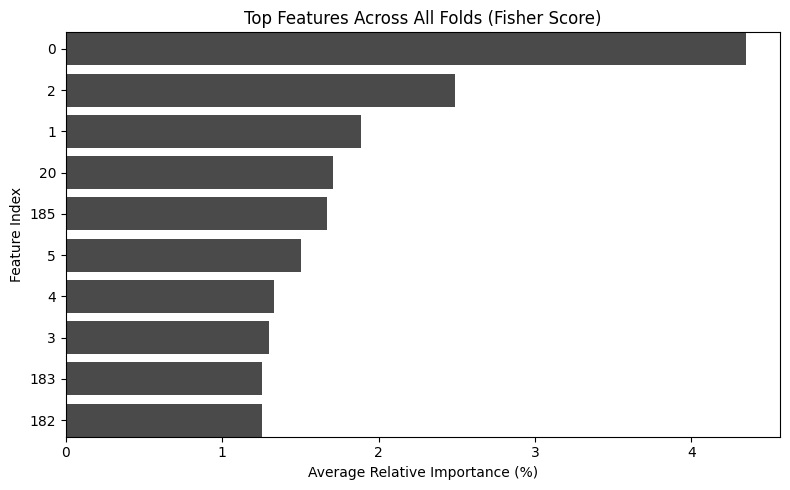

In [57]:
plt.figure(figsize=(8, 5))  # taller figure for many features
bars = plt.barh(df_sorted.index[-10:].astype(str), df_sorted.values[-10:], color='#4A4A4A')  # graphite color

plt.xlabel("Average Relative Importance (%)")
plt.ylabel("Feature Index")
plt.title("Top Features Across All Folds (Fisher Score)")

plt.margins(y=0)
plt.tight_layout()
plt.savefig("appendix_top10.png", bbox_inches='tight')
plt.show()

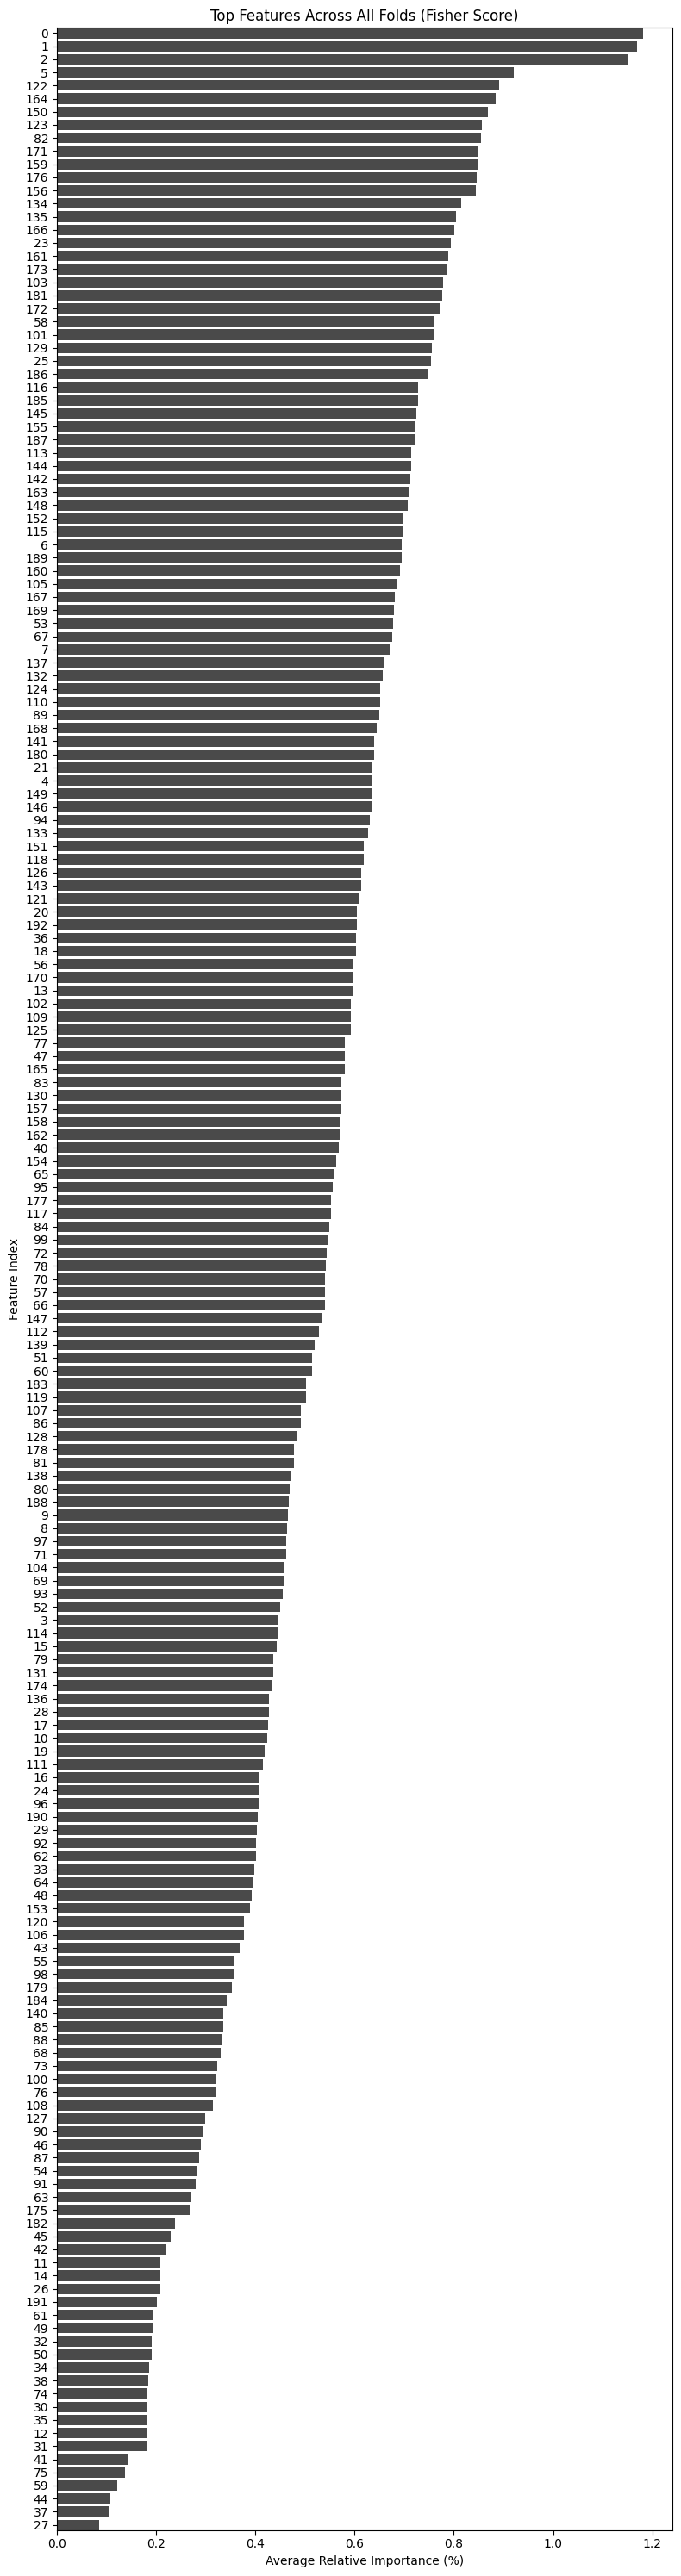

In [48]:
plt.figure(figsize=(8, 30))  # taller figure for many features
bars = plt.barh(df_sorted.index.astype(str), df_sorted.values, color='#4A4A4A')  # graphite color

plt.xlabel("Average Relative Importance (%)")
plt.ylabel("Feature Index")
plt.title("Top Features Across All Folds (Fisher Score)")

plt.margins(y=0)
plt.tight_layout()
plt.savefig("appendix.png", bbox_inches='tight')
plt.show()

In [ ]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=720
num_fea=125
a=create_index(kfold,totalsize)
savedir='ravdess_gender_female'

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=kfold, shuffle=True, random_state=42)

fold = 0
for train_idx, test_idx in skf.split(X3, y2):
    print(f"\n===== Fold {fold} =====")
    print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")

    # Split data
    X_train, X_test = X3.iloc[train_idx, :], X3.iloc[test_idx, :]
    y_train, y_test = y1[train_idx, :], y1[test_idx, :]
    y_train_fs, y_test_fs = y2[train_idx], y2[test_idx]  # for fisher score

    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score.fisher_score(X_train_scaled, y_train_fs)
    sorted_indices = np.argsort(score)[::-1]
    fs_indices = sorted_indices[:num_fea]

    print(f"Top {num_fea} features: {fs_indices[:10]} ...")

    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    # Build and compile model
    m1 = model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {fold} Test Accuracy: {score_eval[1]:.4f}")

    # Save test data for reproducibility
    np.save(os.path.join(savedir, f"X_test_fold{fold}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{fold}.npy"), y_test)

    # Save model
    model_name = f"Model_{fold}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{fold}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)

    fold += 1

print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")
    


===== Fold 0 =====
Train: 576 | Test: 145
Top 125 features: [  0   2   1   7  10   4 102  42 172 152] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.1927 - loss: 2.2730 - val_accuracy: 0.2069 - val_loss: 2.0566
Epoch 2/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.2396 - loss: 1.9503 - val_accuracy: 0.1793 - val_loss: 2.0640
Epoch 3/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3142 - loss: 1.7832 - val_accuracy: 0.1793 - val_loss: 2.0774
Epoch 4/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3733 - loss: 1.6977 - val_accuracy: 0.1724 - val_loss: 2.0932
Epoch 5/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3993 - loss: 1.6253 - val_accuracy: 0.1655 - val_loss: 2.1028
Epoch 6/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.4688 - loss: 1.5135 - val_accuracy: 0.1655 - val_loss: 2.1096
Epoch 7/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.4913 - loss: 1.4715 - val_accuracy: 0.1724 - val_loss: 2.1149
Epoch 8/700
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5191 - loss: 1.4150 - val_accuracy: 0.1724 - val_l

Fold 0 Test Accuracy: 0.7241

===== Fold 1 =====
Train: 577 | Test: 144
Top 125 features: [  0   3   1   9   7   5 115  42 165 138] ...


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.1542 - loss: 2.1313 - val_accuracy: 0.1458 - val_loss: 2.0761
Epoch 2/700
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.2721 - loss: 1.8978 - val_accuracy: 0.1597 - val_loss: 2.0832
Epoch 3/700
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.3397 - loss: 1.7663 - val_accuracy: 0.1389 - val_loss: 2.0983
Epoch 4/700
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.3934 - loss: 1.6325 - val_accuracy: 0.1389 - val_loss: 2.1163
Epoch 5/700
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.4263 - loss: 1.5499 - val_accuracy: 0.1528 - val_loss: 2.1347
Epoch 6/700
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.5026 - loss: 1.4669 - val_accuracy: 0.1319 - val_loss: 2.1594
Epoch 7/700
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5165 - loss: 1.4245 - val_accuracy: 0.1389 - val_loss: 2.1865
Epoch 8/700
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.5303 - loss: 1.4121 - val_accuracy: 0.1389 - val_l

Fold 3 Test Accuracy: 0.5833

===== Fold 4 =====
Train: 577 | Test: 144
Top 125 features: [  0   2   1   6   8   5  77  82 159 111] ...


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/700
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.1837 - loss: 2.2396 - val_accuracy: 0.1042 - val_loss: 2.0732
Epoch 2/700
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.2600 - loss: 1.9142 - val_accuracy: 0.0833 - val_loss: 2.0800
Epoch 3/700
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.3380 - loss: 1.7453 - val_accuracy: 0.0972 - val_loss: 2.0886
Epoch 4/700
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3692 - loss: 1.6576 - val_accuracy: 0.0833 - val_loss: 2.0988
Epoch 5/700
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4367 - loss: 1.5825 - val_accuracy: 0.1319 - val_loss: 2.1116
Epoch 6/700
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5199 - loss: 1.4580 - val_accuracy: 0.1250 - val_loss: 2.1234
Epoch 7/700
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5147 - loss: 1.4314 - val_accuracy: 0.1389 - val_loss: 2.1380
Epoch 8/700
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5546 - loss: 1.3506 - val_accuracy: 0.

Fold 4 Test Accuracy: 0.7083

===== Cross-validation results =====
Fold 0: Loss=1.1447, Accuracy=0.7241
Fold 1: Loss=1.2286, Accuracy=0.6597
Fold 2: Loss=1.3233, Accuracy=0.6389
Fold 3: Loss=1.3389, Accuracy=0.5833
Fold 4: Loss=1.2267, Accuracy=0.7083

Average accuracy: 0.6629


In [2]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix, classification_report

savedir = 'ravdess_gender_female'
num_folds = 5
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

fold_reports = []
fold_macro_f1 = []

for i in range(num_folds):
    model_name = f"Model_{i}"
    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")
    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    report_dict = classification_report(y_true_labels, y_pred_labels,
                                        target_names=listik, digits=4, output_dict=True)
    fold_reports.append(report_dict)
    fold_macro_f1.append(report_dict['macro avg']['f1-score'])

    print(f"\n{'='*60}")
    print(f"Fold {i}: Accuracy = {acc:.2f}%")
    print(f"{'='*60}")
    print(classification_report(y_true_labels, y_pred_labels,
                                target_names=listik, digits=4))

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)

mean_acc = np.mean(accuracies)
print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))
n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")


# Macro-F1 summary
macro_f1_arr = np.array(fold_macro_f1)
mean_macro_f1 = np.mean(macro_f1_arr)
std_macro_f1 = np.std(macro_f1_arr)
ci95_f1 = 1.96 * (std_macro_f1 / np.sqrt(num_folds))
print(f"\nMacro-F1: {mean_macro_f1:.4f} ± {std_macro_f1:.4f}  "
      f"\n95% CI: [{mean_macro_f1 - ci95_f1:.4f}, {mean_macro_f1 + ci95_f1:.4f}]")

# Per-class precision / recall / F1 (mean ± SD across folds)
print(f"\n{' Per-Class Metrics (mean ± SD across folds)':=^93}\n")
print(f"{'Class':<12} {'Precision':>20} {'Recall':>20} {'F1-Score':>20} {'Support':>17}")
print("-" * 93)
for cls in listik:
    p = np.array([r[cls]['precision'] for r in fold_reports])
    r = np.array([r[cls]['recall'] for r in fold_reports])
    f = np.array([r[cls]['f1-score'] for r in fold_reports])
    s = np.array([r[cls]['support'] for r in fold_reports])
    print(f"{cls:<12}        "
          f"{np.mean(p):>6.4f} ± {np.std(p):<6.4f}       "
          f"{np.mean(r):>6.4f} ± {np.std(r):<6.4f}       "
          f"{np.mean(f):>6.4f} ± {np.std(f):<6.4f}     "
          f"{np.mean(s):>8.1f}")
print("-" * 93)

/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(



Fold 0: Accuracy = 72.41%
              precision    recall  f1-score   support

       angry     0.6667    0.6000    0.6316        10
        calm     0.7391    0.8947    0.8095        19
     disgust     0.6522    0.7500    0.6977        20
     fearful     0.8000    0.6316    0.7059        19
       happy     0.8235    0.7368    0.7778        19
     neutral     0.8095    0.8947    0.8500        19
         sad     0.6667    0.3158    0.4286        19
   surprised     0.6429    0.9000    0.7500        20

    accuracy                         0.7241       145
   macro avg     0.7251    0.7155    0.7064       145
weighted avg     0.7276    0.7241    0.7113       145


Fold 1: Accuracy = 65.97%
              precision    recall  f1-score   support

       angry     0.4286    0.3000    0.3529        10
        calm     0.6538    0.8947    0.7556        19
     disgust     0.6923    0.4737    0.5625        19
     fearful     0.6190    0.6500    0.6341        20
       happy     0.6296 

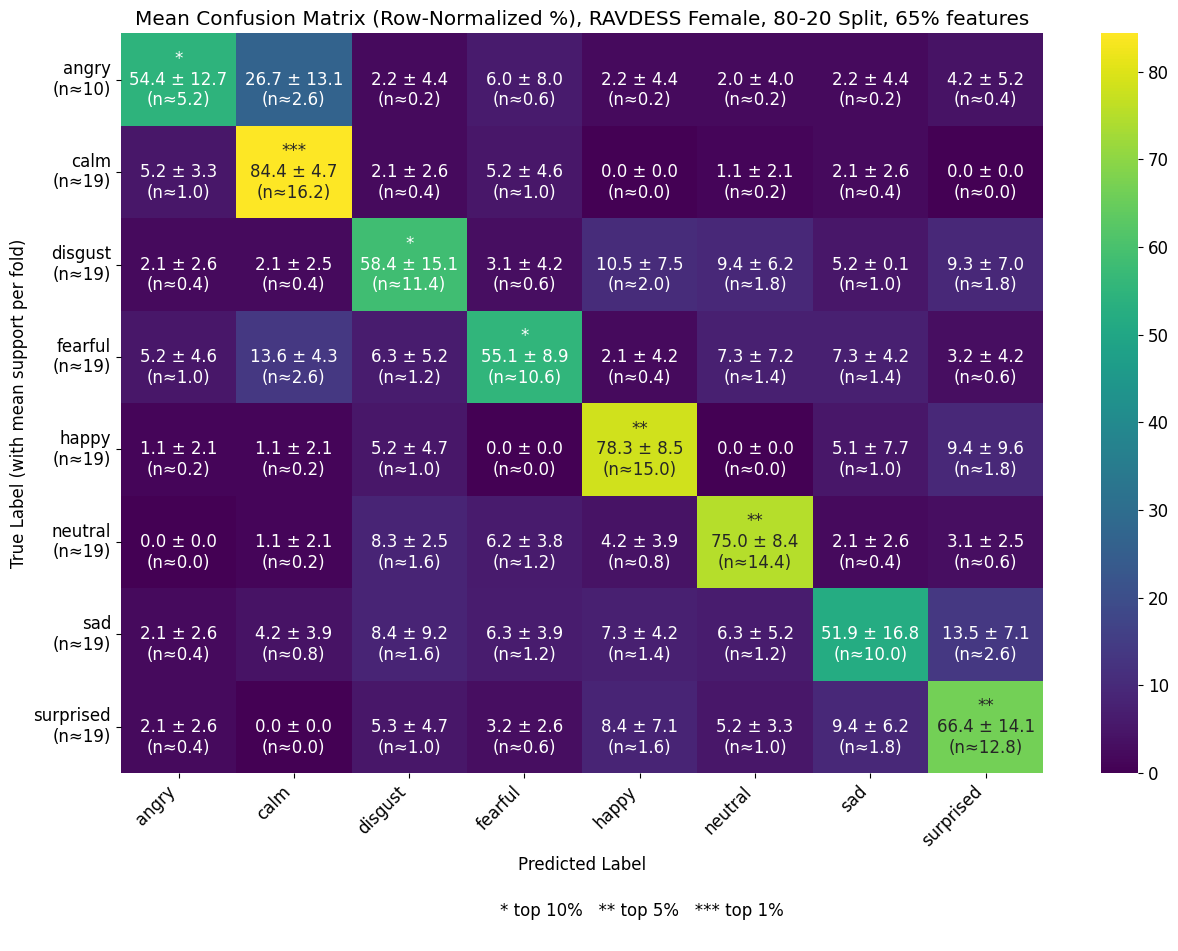

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 12})

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

np.save('cm_ravdess_gender_female.npy', conf_matrices_percent)

mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

# Mean raw counts per fold
mean_counts = np.mean(conf_matrices, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols + raw counts
labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        val = mean_cm[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels[i, j] = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}\n(n≈{mean_counts[i, j]:.1f})"

listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

# Per-class support (mean samples per true class per fold)
mean_support = np.mean(conf_matrices.sum(axis=2), axis=0)
row_labels = [f"{name}\n(n≈{sup:.0f})" for name, sup in zip(listik, mean_support)]

# Plot
plt.figure(figsize=(13, 9))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)
ax.set_xticks(np.arange(len(listik)) + 0.5)
ax.set_yticks(np.arange(len(listik)) + 0.5)
ax.set_xticklabels(listik, rotation=45, ha="right")
ax.set_yticklabels(row_labels, rotation=0)
plt.title("Mean Confusion Matrix (Row-Normalized %), RAVDESS Female, 80-20 Split, 65% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label (with mean support per fold)")
plt.tight_layout()
plt.figtext(0.5, -0.05,
            "* top 10%   ** top 5%   *** top 1%\n",
            ha="center", fontsize=12)
plt.savefig("cm_ravdess_gender_female.eps", bbox_inches='tight')
plt.show()

In [4]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix, classification_report

savedir = 'ravdess_gender_male'
num_folds = 5
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices_male = []

listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

fold_reports = []
fold_macro_f1 = []

for i in range(num_folds):
    model_name = f"Model_{i}"
    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")
    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices_male.append(cm)

    report_dict = classification_report(y_true_labels, y_pred_labels,
                                        target_names=listik, digits=4, output_dict=True)
    fold_reports.append(report_dict)
    fold_macro_f1.append(report_dict['macro avg']['f1-score'])

    print(f"\n{'='*60}")
    print(f"Fold {i}: Accuracy = {acc:.2f}%")
    print(f"{'='*60}")
    print(classification_report(y_true_labels, y_pred_labels,
                                target_names=listik, digits=4))

# array: (num_folds, num_classes, num_classes)
conf_matrices_male = np.array(conf_matrices_male)

mean_acc = np.mean(accuracies)
print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))
n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")


# Macro-F1 summary
macro_f1_arr = np.array(fold_macro_f1)
mean_macro_f1 = np.mean(macro_f1_arr)
std_macro_f1 = np.std(macro_f1_arr)
ci95_f1 = 1.96 * (std_macro_f1 / np.sqrt(num_folds))
print(f"\nMacro-F1: {mean_macro_f1:.4f} ± {std_macro_f1:.4f}  "
      f"\n95% CI: [{mean_macro_f1 - ci95_f1:.4f}, {mean_macro_f1 + ci95_f1:.4f}]")

# Per-class precision / recall / F1 (mean ± SD across folds)
print(f"\n{' Per-Class Metrics (mean ± SD across folds)':=^93}\n")
print(f"{'Class':<12} {'Precision':>20} {'Recall':>20} {'F1-Score':>20} {'Support':>17}")
print("-" * 93)
for cls in listik:
    p = np.array([r[cls]['precision'] for r in fold_reports])
    r = np.array([r[cls]['recall'] for r in fold_reports])
    f = np.array([r[cls]['f1-score'] for r in fold_reports])
    s = np.array([r[cls]['support'] for r in fold_reports])
    print(f"{cls:<12}        "
          f"{np.mean(p):>6.4f} ± {np.std(p):<6.4f}       "
          f"{np.mean(r):>6.4f} ± {np.std(r):<6.4f}       "
          f"{np.mean(f):>6.4f} ± {np.std(f):<6.4f}     "
          f"{np.mean(s):>8.1f}")
print("-" * 93)

/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(



Fold 0: Accuracy = 75.00%
              precision    recall  f1-score   support

       angry     1.0000    1.0000    1.0000        10
        calm     0.8182    0.9474    0.8780        19
     disgust     0.5455    0.6316    0.5854        19
     fearful     0.8125    0.6842    0.7429        19
       happy     0.7895    0.7500    0.7692        20
     neutral     0.7857    0.5789    0.6667        19
         sad     0.6957    0.8421    0.7619        19
   surprised     0.7222    0.6842    0.7027        19

    accuracy                         0.7500       144
   macro avg     0.7711    0.7648    0.7633       144
weighted avg     0.7570    0.7500    0.7486       144


Fold 1: Accuracy = 77.08%
              precision    recall  f1-score   support

       angry     0.5000    0.8000    0.6154        10
        calm     0.8667    0.6842    0.7647        19
     disgust     0.8000    0.6316    0.7059        19
     fearful     0.8462    0.5789    0.6875        19
       happy     0.7500 

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 11})

conf_matrices_percent_male = conf_matrices_male / conf_matrices_male.sum(axis=2, keepdims=True) * 100


mean_cm_2 = np.mean(conf_matrices_percent_male, axis=0)
std_cm_2 = np.std(conf_matrices_percent_male, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm_2.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols
labels_2 = np.empty(mean_cm_2.shape, dtype=object)
for i in range(mean_cm_2.shape[0]):
    for j in range(mean_cm_2.shape[1]):
        val = mean_cm_2[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels_2[i, j] = f"{symbol}\n{val:.1f} ± {std_cm_2[i, j]:.1f}"


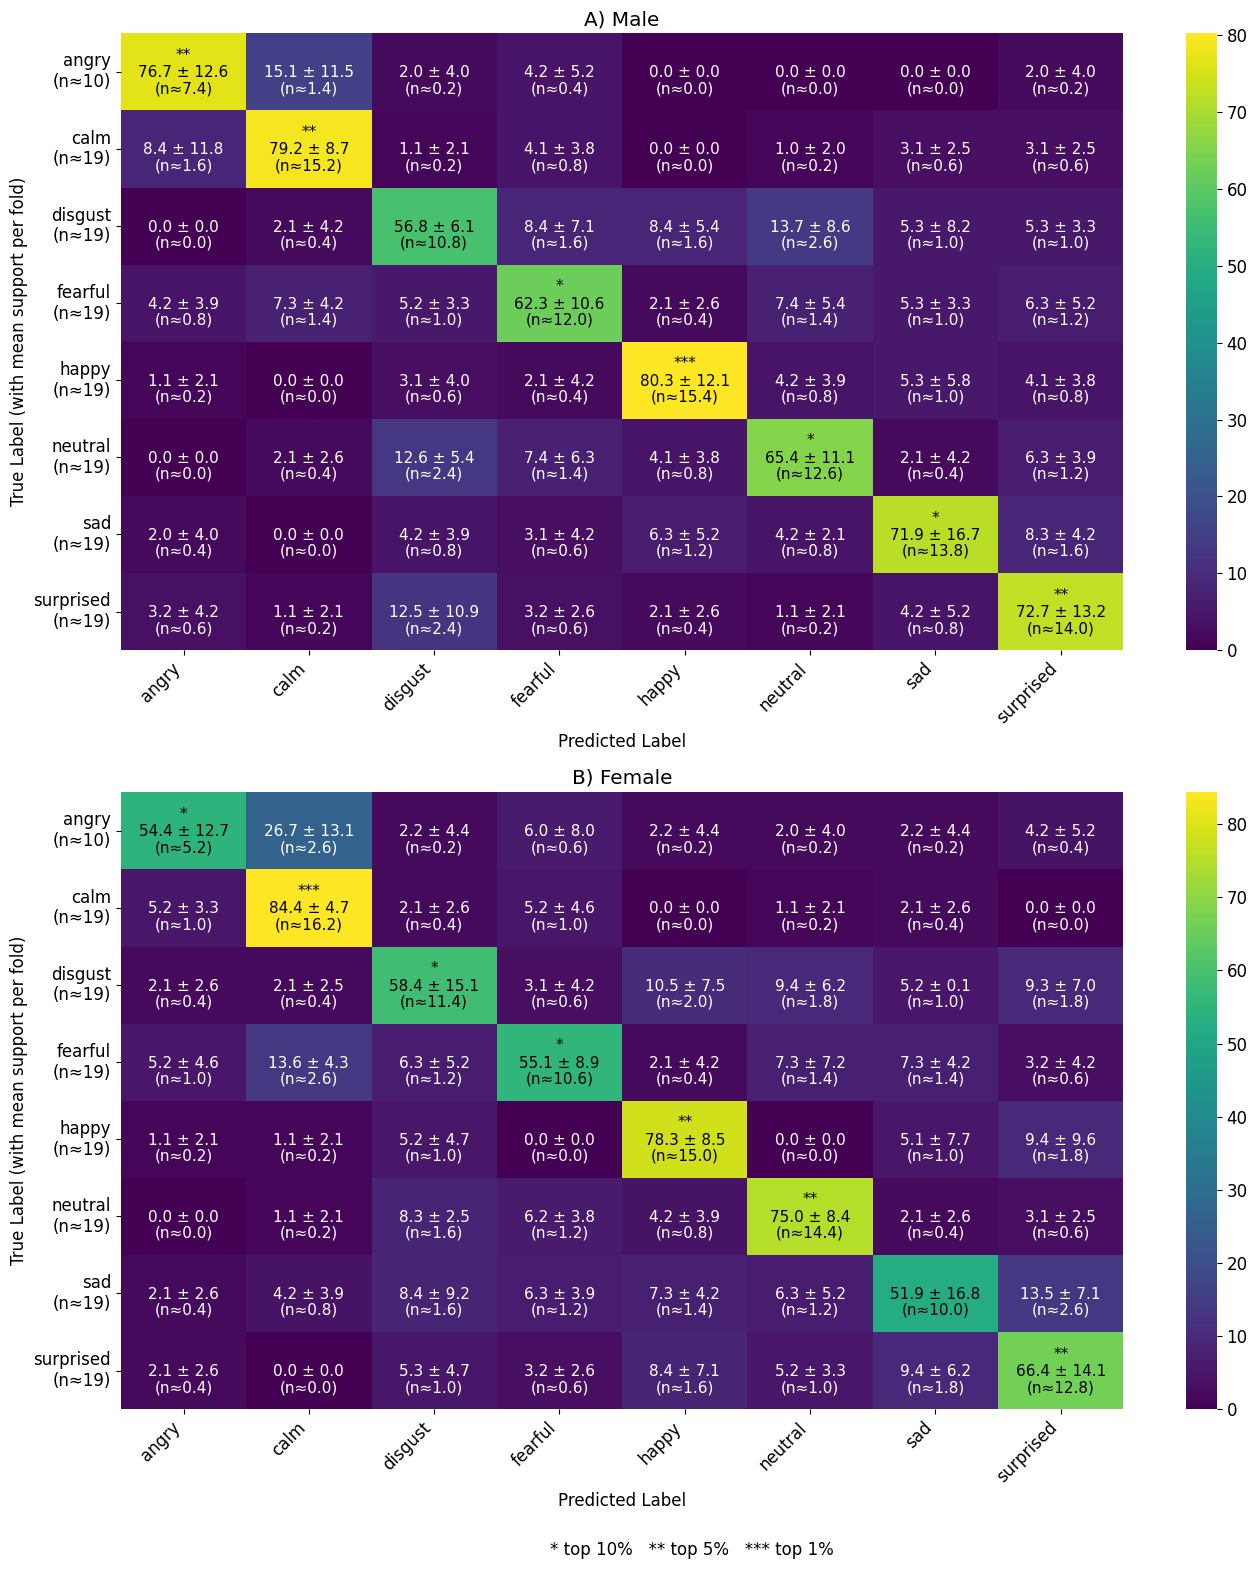

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 12})
listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

fig, axes = plt.subplots(2, 1, figsize=(14, 16))

# Helper function for manual two-size annotations
def annotate_heatmap(ax, mean_cm, std_cm, mean_counts, thr_90, thr_95, thr_99):
    for i in range(mean_cm.shape[0]):
        for j in range(mean_cm.shape[1]):
            val = mean_cm[i, j]
            symbol = ""
            if val >= thr_99:
                symbol = "***"
            elif val >= thr_95:
                symbol = "**"
            elif val >= thr_90:
                symbol = "*"

            text_color = "white" if val < 50 else "black"

            main_text = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}"
            ax.text(j + 0.5, i + 0.4, main_text,
                    ha='center', va='center',
                    fontsize=11, color=text_color)

            count_text = f"(n≈{mean_counts[i, j]:.1f})"
            ax.text(j + 0.5, i + 0.72, count_text,
                    ha='center', va='center',
                    fontsize=11, color=text_color)
            

# For female (conf_matrices is the raw count matrices)
mean_counts = np.mean(conf_matrices, axis=0)

# For male (conf_matrices_2 is the raw count matrices)
mean_counts_2 = np.mean(conf_matrices_male, axis=0)

# ---------------------------------------
# A) Male heatmap (TOP)
# ---------------------------------------
ax1 = axes[0]

flat_vals_2 = mean_cm_2.flatten()
thr_90_2 = np.percentile(flat_vals_2, 90)
thr_95_2 = np.percentile(flat_vals_2, 95)
thr_99_2 = np.percentile(flat_vals_2, 99)

mean_support_2 = np.mean(conf_matrices_male.sum(axis=2), axis=0)
row_labels_2 = [f"{name}\n(n≈{sup:.0f})" for name, sup in zip(listik, mean_support_2)]

sns.heatmap(mean_cm_2, annot=False, cmap="viridis", cbar=True, ax=ax1)
annotate_heatmap(ax1, mean_cm_2, std_cm_2, mean_counts_2, thr_90_2, thr_95_2, thr_99_2)

ax1.set_xticks(np.arange(len(listik)) + 0.5)
ax1.set_yticks(np.arange(len(listik)) + 0.5)
ax1.set_xticklabels(listik, rotation=45, ha="right")
ax1.set_yticklabels(row_labels_2, rotation=0)
ax1.set_title("A) Male")
ax1.set_xlabel("Predicted Label")
ax1.set_ylabel("True Label (with mean support per fold)")

# ---------------------------------------
# B) Female heatmap (BOTTOM)
# ---------------------------------------
ax2 = axes[1]

flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

mean_support = np.mean(conf_matrices.sum(axis=2), axis=0)
row_labels = [f"{name}\n(n≈{sup:.0f})" for name, sup in zip(listik, mean_support)]

sns.heatmap(mean_cm, annot=False, cmap="viridis", cbar=True, ax=ax2)
annotate_heatmap(ax2, mean_cm, std_cm, mean_counts, thr_90, thr_95, thr_99)

ax2.set_xticks(np.arange(len(listik)) + 0.5)
ax2.set_yticks(np.arange(len(listik)) + 0.5)
ax2.set_xticklabels(listik, rotation=45, ha="right")
ax2.set_yticklabels(row_labels, rotation=0)
ax2.set_title("B) Female")
ax2.set_xlabel("Predicted Label")
ax2.set_ylabel("True Label (with mean support per fold)")

# Shared caption
fig.text(0.5, 0.01,
         "* top 10%   ** top 5%   *** top 1%\n",
         ha="center", fontsize=12)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("cm_ravdess_gender_ab.eps", bbox_inches='tight')
plt.show()